In [1]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import os
import time

In [2]:
# Check device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Using Apple M3 GPU (Metal)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✓ Using NVIDIA GPU")
else:
    device = torch.device("cpu")
    print(" Using CPU")

print(f"Device: {device}")

✓ Using NVIDIA GPU
Device: cuda


In [5]:

# Load splits
train_data = pd.read_pickle('/content/train_data_final.pkl')
val_data_masked = pd.read_pickle('/content/val_data_masked.pkl')
test_data_masked = pd.read_pickle('/content/test_data_masked.pkl')


val_ground_truth = pd.read_pickle('/content/val_ground_truth.pkl')
test_ground_truth = pd.read_pickle('/content/test_ground_truth.pkl')


val_mask_indicator = pd.read_pickle('/content/val_mask_indices.pkl')
test_mask_indicator = pd.read_pickle('/content/test_mask_indices.pkl')



# Features to impute
features_to_impute = val_ground_truth.columns.tolist()

print(f"\n Loaded data:")
print(f"  • Train: {train_data.shape}")
print(f"  • Val: {val_data_masked.shape}")
print(f"  • Test: {test_data_masked.shape}")
print(f"  • Features to impute: {len(features_to_impute)}")


 Loaded data:
  • Train: (143459, 47)
  • Val: (30741, 47)
  • Test: (30742, 47)
  • Features to impute: 37


In [10]:
continuous_impute = [
    'ping_ms', 'datarate', 'jitter', 'Latitude', 'Longitude',
    'Altitude', 'speed_kmh', 'COG', 'precipIntensity',
    'precipProbability', 'temperature', 'humidity', 'windSpeed',
    'Traffic Jam Factor', 'Traffic Distance', 'Pos in Ref Round',
    'measurement', 'PCell_RSRP_max', 'PCell_RSRQ_max',
    'PCell_RSSI_max', 'PCell_SNR_1', 'PCell_SNR_2',
    'PCell_Downlink_Num_RBs', 'PCell_Downlink_TB_Size',
    'PCell_Downlink_Average_MCS', 'PCell_Uplink_Num_RBs',
    'PCell_Uplink_TB_Size', 'PCell_Uplink_Tx_Power_(dBm)',
    'PCell_Downlink_bandwidth_MHz', 'PCell_Uplink_bandwidth_MHz',
    'PCell_Band_Indicator', 'target_datarate',
    'PCell_DL_RBs_MCS_Low', 'PCell_DL_RBs_MCS_Mid',
    'PCell_DL_RBs_MCS_High',
]

# Categorical features (encoded as input, NOT reconstructed)
categorical_raw = [ 'PCell_freq_MHz',
                   'PCell_Downlink_frequency']

# Static features (no missing, constant context)
static_features = [
    'operator',
    'device_pc1', 'device_pc2', 'device_pc3',
     'direction_uplink',
    'measured_qos_delay',
    'hour', 'day_of_week',
]

print(f"Continuous to impute (targets): {len(continuous_impute)}")
print(f"Categorical (input only):       {len(categorical_raw)}")
print(f"Static features:                {len(static_features)}")

Continuous to impute (targets): 35
Categorical (input only):       2
Static features:                8


In [11]:

freq_cols = ['PCell_freq_MHz', 'PCell_Downlink_frequency']

# Build frequency map for Cell_ID from train only
#cell_freq_map = train_data['PCell_Cell_ID'].value_counts(normalize=True).to_dict()

def encode_cell_freq(df, dummy_columns=None):
    df = df.copy()

    # Frequency encode Cell_ID
    #df['PCell_Cell_ID_missing'] = df['PCell_Cell_ID'].isna().astype(float)
    #df['PCell_Cell_ID_encoded'] = df['PCell_Cell_ID'].map(cell_freq_map).fillna(0)

    # Fill NaN with -1 for freq columns
    for col in freq_cols:
        df[col] = df[col].fillna(-1)

    # One-hot encode
    dummies = pd.get_dummies(
        df[freq_cols],
        columns=freq_cols,
        prefix=['band', 'ul_earfcn'],
        dtype=int
    )

    if dummy_columns is not None:
        dummies = dummies.reindex(columns=dummy_columns, fill_value=0)

    return df, dummies, dummies.columns.tolist()

train_enc, train_dummies, dummy_cols = encode_cell_freq(train_data)
val_enc, val_dummies, _ = encode_cell_freq(val_data_masked, dummy_columns=dummy_cols)
test_enc, test_dummies, _ = encode_cell_freq(test_data_masked, dummy_columns=dummy_cols)

print(f"\n✓ Categorical encoding done:")

print(f"  Dummy columns ({len(dummy_cols)}): {dummy_cols}")


✓ Categorical encoding done:
  Dummy columns (16): ['band_-1.0', 'band_700.0', 'band_900.0', 'band_1800.0', 'band_2000.0', 'band_2100.0', 'band_2600.0', 'ul_earfcn_-1.0', 'ul_earfcn_125.0', 'ul_earfcn_475.0', 'ul_earfcn_1300.0', 'ul_earfcn_1801.0', 'ul_earfcn_2850.0', 'ul_earfcn_3050.0', 'ul_earfcn_3749.0', 'ul_earfcn_9460.0']


In [12]:
def clip_outliers_per_feature(data, features, lower_pct=0.5, upper_pct=99.5,
                               reference_data=None):
    data_clipped = data.copy()
    clipping_bounds = {}
    for feat in features:
        if feat not in data.columns:
            continue
        if reference_data is not None:
            ref_col = reference_data[feat].dropna()
        else:
            ref_col = data[feat].dropna()
        if len(ref_col) == 0:
            continue
        lower_bound = np.percentile(ref_col, lower_pct)
        upper_bound = np.percentile(ref_col, upper_pct)
        clipping_bounds[feat] = (lower_bound, upper_bound)
        mask = data_clipped[feat].notna()
        data_clipped.loc[mask, feat] = data_clipped.loc[mask, feat].clip(
            lower=lower_bound, upper=upper_bound
        )
    return data_clipped, clipping_bounds

print("Clipping continuous features...")
train_clipped, clipping_bounds = clip_outliers_per_feature(
    train_data, continuous_impute)
val_clipped, _ = clip_outliers_per_feature(
    val_data_masked, continuous_impute, reference_data=train_data)
test_clipped, _ = clip_outliers_per_feature(
    test_data_masked, continuous_impute, reference_data=train_data)

# Clip ground truth
val_gt_clipped, _ = clip_outliers_per_feature(
    val_ground_truth, continuous_impute, reference_data=train_data)
test_gt_clipped, _ = clip_outliers_per_feature(
    test_ground_truth, continuous_impute, reference_data=train_data)

print(f"✓ Clipping done ({len(clipping_bounds)} features clipped)")

Clipping continuous features...
✓ Clipping done (35 features clipped)


In [13]:
cont_scaler = StandardScaler()
train_cont = cont_scaler.fit_transform(train_clipped[continuous_impute].values)
val_cont = cont_scaler.transform(val_clipped[continuous_impute].values)
test_cont = cont_scaler.transform(test_clipped[continuous_impute].values)

# Encoded categoricals — already 0/1 or small floats, no scaling needed

train_cat_enc = np.hstack([
    train_dummies.values
])
val_cat_enc = np.hstack([
    val_dummies.values
])
test_cat_enc = np.hstack([
    test_dummies.values
])

# Full input: [continuous | encoded_categorical]
train_scaled = np.hstack([train_cont, train_cat_enc])
val_scaled = np.hstack([val_cont, val_cat_enc])
test_scaled = np.hstack([test_cont, test_cat_enc])

# Static features
train_static_df = train_data[static_features].fillna(0)
val_static_df = val_data_masked[static_features].fillna(0)
test_static_df = test_data_masked[static_features].fillna(0)

static_scaler = MinMaxScaler()
train_static = static_scaler.fit_transform(train_static_df.values)
val_static = static_scaler.transform(val_static_df.values)
test_static = static_scaler.transform(test_static_df.values)

n_continuous = len(continuous_impute)
n_cat_encoded = train_cat_enc.shape[1]
n_input = train_scaled.shape[1]
n_static = len(static_features)

print(f"\n✓ Scaling done:")
print(f"  Full input: {train_scaled.shape} ({n_continuous} continuous + {n_cat_encoded} encoded cat)")
print(f"  Static: {train_static.shape}")


✓ Scaling done:
  Full input: (143459, 51) (35 continuous + 16 encoded cat)
  Static: (143459, 8)


In [14]:
def compute_time_deltas(timestamps):
    ts = pd.to_datetime(timestamps)
    deltas = ts.diff().dt.total_seconds().fillna(0).values
    deltas = np.clip(deltas, 0, 60)
    deltas = deltas / 60.0
    return deltas

train_deltas = compute_time_deltas(train_data['timestamp'])
val_deltas = compute_time_deltas(val_data_masked['timestamp'])
test_deltas = compute_time_deltas(test_data_masked['timestamp'])

print(f"✓ Time deltas computed")
print(f"  Train mean: {train_deltas.mean():.4f} min")


✓ Time deltas computed
  Train mean: 0.0043 min


In [15]:
SEQ_LEN = 20

def create_sequences(scaled_data, static_data, deltas, seq_len):
    n_samples = len(scaled_data) - seq_len + 1
    n_features = scaled_data.shape[1]
    n_static = static_data.shape[1]

    mask = (~np.isnan(scaled_data)).astype(np.float32)
    data_filled = np.nan_to_num(scaled_data, nan=0.0)

    sequences = np.zeros((n_samples, seq_len, n_features), dtype=np.float32)
    masks = np.zeros((n_samples, seq_len, n_features), dtype=np.float32)
    time_gaps = np.zeros((n_samples, seq_len), dtype=np.float32)
    statics = np.zeros((n_samples, n_static), dtype=np.float32)

    for i in range(n_samples):
        sequences[i] = data_filled[i:i+seq_len]
        masks[i] = mask[i:i+seq_len]
        time_gaps[i] = deltas[i:i+seq_len]
        statics[i] = static_data[i+seq_len-1]

    return sequences, masks, time_gaps, statics

print(f"Creating sequences (seq_len={SEQ_LEN})...")
train_seq, train_mask, train_gaps, train_stat = create_sequences(
    train_scaled, train_static, train_deltas, SEQ_LEN)
val_seq, val_mask, val_gaps, val_stat = create_sequences(
    val_scaled, val_static, val_deltas, SEQ_LEN)
test_seq, test_mask, test_gaps, test_stat = create_sequences(
    test_scaled, test_static, test_deltas, SEQ_LEN)

print(f"✓ Sequences created:")
print(f"  Train: {train_seq.shape}")
print(f"  Val:   {val_seq.shape}")
print(f"  Test:  {test_seq.shape}")

Creating sequences (seq_len=20)...
✓ Sequences created:
  Train: (143440, 20, 51)
  Val:   (30722, 20, 51)
  Test:  (30723, 20, 51)


In [16]:
class GRUDDataset(Dataset):
    def __init__(self, sequences, masks, time_gaps, statics,
                 n_continuous, noise_ratio=0.2, training=True):
        self.sequences = sequences
        self.masks = masks
        self.time_gaps = time_gaps
        self.statics = statics
        self.n_continuous = n_continuous
        self.noise_ratio = noise_ratio
        self.training = training

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx].copy()
        mask = self.masks[idx].copy()
        gaps = self.time_gaps[idx].copy()
        static = self.statics[idx].copy()

        # Target: only continuous features at last timestep
        target = seq[-1, :self.n_continuous].copy()
        target_mask = mask[-1, :self.n_continuous].copy()

        if self.training:
            last_mask = mask[-1, :self.n_continuous]
            observed = np.where(last_mask > 0)[0]
            if len(observed) > 1:
                n_corrupt = max(1, int(len(observed) * self.noise_ratio))
                corrupt_idx = np.random.choice(observed, n_corrupt, replace=False)
                seq[-1, corrupt_idx] = 0.0
                mask[-1, corrupt_idx] = 0.0

        return (torch.FloatTensor(seq),
                torch.FloatTensor(mask),
                torch.FloatTensor(gaps),
                torch.FloatTensor(static),
                torch.FloatTensor(target),
                torch.FloatTensor(target_mask))

BATCH_SIZE = 256

train_dataset = GRUDDataset(train_seq, train_mask, train_gaps, train_stat,
                            n_continuous, noise_ratio=0.2, training=True)
val_dataset = GRUDDataset(val_seq, val_mask, val_gaps, val_stat,
                          n_continuous, noise_ratio=0.0, training=False)
test_dataset = GRUDDataset(test_seq, test_mask, test_gaps, test_stat,
                           n_continuous, noise_ratio=0.0, training=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✓ Datasets:")
print(f"  Train: {len(train_dataset):,}")
print(f"  Val:   {len(val_dataset):,}")
print(f"  Test:  {len(test_dataset):,}")


✓ Datasets:
  Train: 143,440
  Val:   30,722
  Test:  30,723


In [17]:
class GRUD(nn.Module):
    def __init__(self, input_dim, static_dim, hidden_dim=128, output_dim=None):
        super(GRUD, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim or input_dim

        self.W_gamma_x = nn.Linear(input_dim, input_dim)
        self.W_gamma_h = nn.Linear(input_dim, hidden_dim)
        self.x_mean = nn.Parameter(torch.zeros(input_dim))

        gru_input_dim = input_dim * 2 + static_dim
        self.W_z = nn.Linear(gru_input_dim + hidden_dim, hidden_dim)
        self.W_r = nn.Linear(gru_input_dim + hidden_dim, hidden_dim)
        self.W_h = nn.Linear(gru_input_dim + hidden_dim, hidden_dim)

        self.output_layer = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, self.output_dim)
        )

    def forward(self, x, mask, time_gaps, static):
        batch_size, seq_len, _ = x.shape
        h = torch.zeros(batch_size, self.hidden_dim, device=x.device)

        for t in range(seq_len):
            x_t = x[:, t, :]
            m_t = mask[:, t, :]
            dt = time_gaps[:, t:t+1]

            gamma_x = torch.exp(-torch.relu(self.W_gamma_x(dt.expand(-1, self.input_dim))))
            gamma_h = torch.exp(-torch.relu(self.W_gamma_h(dt.expand(-1, self.input_dim))))

            x_decayed = m_t * x_t + (1 - m_t) * (gamma_x * x_t + (1 - gamma_x) * self.x_mean)
            h = gamma_h * h

            combined = torch.cat([x_decayed, m_t, static], dim=1)
            combined_h = torch.cat([combined, h], dim=1)

            z = torch.sigmoid(self.W_z(combined_h))
            r = torch.sigmoid(self.W_r(combined_h))
            h_tilde_input = torch.cat([combined, r * h], dim=1)
            h_tilde = torch.tanh(self.W_h(h_tilde_input))
            h = (1 - z) * h + z * h_tilde

        output = self.output_layer(h)
        return output


In [18]:
INPUT_DIM = n_input
STATIC_DIM = n_static
HIDDEN_DIM = 128
OUTPUT_DIM = n_continuous

model = GRUD(INPUT_DIM, STATIC_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)

with torch.no_grad():
    train_means = np.nanmean(train_scaled, axis=0)
    model.x_mean.copy_(torch.FloatTensor(train_means))

# Inverse variance weights — only for continuous features
col_variances = np.nanvar(train_cont, axis=0)
col_weights = 1.0 / (col_variances + 1e-8)
col_weights = col_weights / col_weights.mean()
col_weights_tensor = torch.FloatTensor(col_weights).to(device)

def weighted_masked_mse(outputs, targets, mask, weights):
    squared_error = (outputs - targets) ** 2
    weighted_error = squared_error * weights.unsqueeze(0)
    masked_error = weighted_error * mask
    loss = masked_error.sum() / (mask.sum() + 1e-8)
    return loss

print(f"\n✓ GRU-D Model:")
print(f"  Input:  {INPUT_DIM} ({n_continuous} cont + {n_cat_encoded} cat)")
print(f"  Static: {STATIC_DIM}")
print(f"  Hidden: {HIDDEN_DIM}")
print(f"  Output: {OUTPUT_DIM} (continuous only)")
print(f"  Params: {sum(p.numel() for p in model.parameters()):,}")



✓ GRU-D Model:
  Input:  51 (35 cont + 16 cat)
  Static: 8
  Hidden: 128
  Output: 35 (continuous only)
  Params: 122,162


In [19]:



optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)
NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 15

history = {'train_loss': [], 'val_loss': [], 'epoch_times': []}
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\n🚀 Starting GRU-D training...")
print(f"{'Epoch':<8s} {'Train Loss':<15s} {'Val Loss':<15s} {'Time':<10s} {'Status'}")
print("─" * 70)

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()

    model.train()
    train_losses = []
    for seq, mask, gaps, static, target, target_mask in train_loader:
        seq = seq.to(device)
        mask = mask.to(device)
        gaps = gaps.to(device)
        static = static.to(device)
        target = target.to(device)
        target_mask = target_mask.to(device)

        optimizer.zero_grad()
        outputs = model(seq, mask, gaps, static)
        loss = weighted_masked_mse(outputs, target, target_mask, col_weights_tensor)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)

    model.eval()
    val_losses = []
    with torch.no_grad():
        for seq, mask, gaps, static, target, target_mask in val_loader:
            seq = seq.to(device)
            mask = mask.to(device)
            gaps = gaps.to(device)
            static = static.to(device)
            target = target.to(device)
            target_mask = target_mask.to(device)

            outputs = model(seq, mask, gaps, static)
            loss = weighted_masked_mse(outputs, target, target_mask, col_weights_tensor)
            val_losses.append(loss.item())

    avg_val_loss = np.mean(val_losses)
    epoch_time = time.time() - epoch_start

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['epoch_times'].append(epoch_time)
    scheduler.step(avg_val_loss)

    status = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        status = "✓ Best"
    else:
        patience_counter += 1
        status = f"({patience_counter}/{EARLY_STOP_PATIENCE})"

    print(f"{epoch+1:<8d} {avg_train_loss:<15.6f} {avg_val_loss:<15.6f} {epoch_time:<10.2f}s {status}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⚠️  Early stopping at epoch {epoch+1}")
        break

model.load_state_dict(best_model_state)
print(f"\n✓ Training complete!")
print(f"  Best val loss: {best_val_loss:.6f}")
print(f"  Total time: {sum(history['epoch_times']):.1f}s")



🚀 Starting GRU-D training...
Epoch    Train Loss      Val Loss        Time       Status
──────────────────────────────────────────────────────────────────────
1        0.199619        0.137562        44.14     s ✓ Best
2        0.116821        0.123093        44.10     s ✓ Best
3        0.106717        0.115982        42.01     s ✓ Best
4        0.099856        0.109257        41.68     s ✓ Best
5        0.094926        0.104788        42.24     s ✓ Best
6        0.091606        0.100036        41.21     s ✓ Best
7        0.089099        0.094969        39.67     s ✓ Best
8        0.086786        0.094956        40.35     s ✓ Best
9        0.086050        0.095326        40.83     s (1/15)
10       0.084522        0.097556        40.16     s (2/15)
11       0.083319        0.089648        41.25     s ✓ Best
12       0.082452        0.088864        42.25     s ✓ Best
13       0.081801        0.089756        41.03     s (1/15)
14       0.081049        0.087695        41.09     s ✓ Best


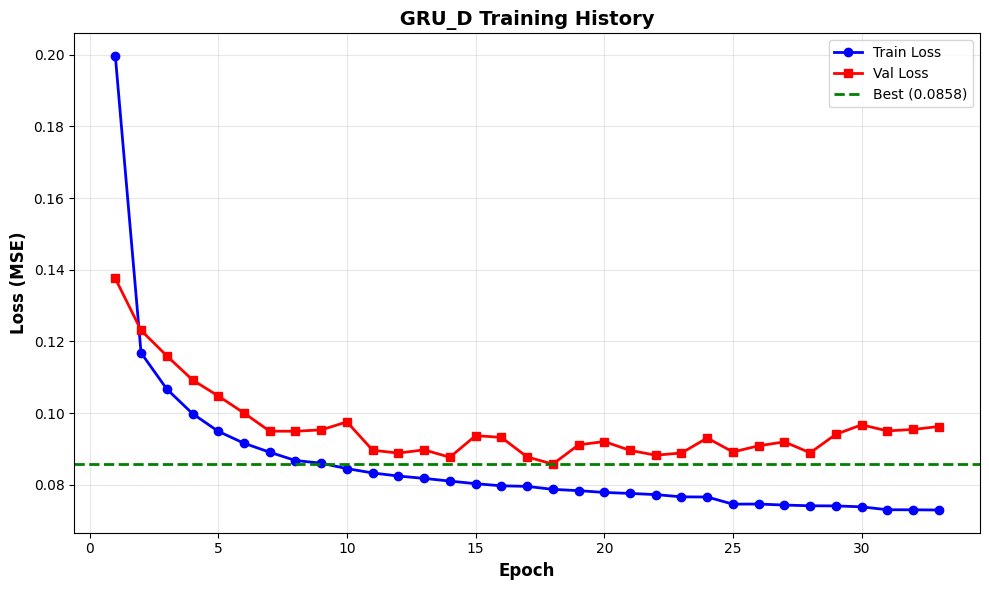


✅ GRU_D TRAINING COMPLETE

📊 RESULTS:
  • Best validation loss: 0.085782
  • Epochs: 33
  • Total time: 1371.8s

🎯 NEXT: Evaluate on test set!



In [20]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

epochs = range(1, len(history['train_loss']) + 1)

ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2, marker='o')
ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2, marker='s')
ax.axhline(y=best_val_loss, color='g', linestyle='--', linewidth=2, label=f'Best ({best_val_loss:.4f})')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
ax.set_title(' GRU_D Training History ', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

print("\n" + "="*80)
print("✅ GRU_D TRAINING COMPLETE")
print("="*80)

print(f"""
📊 RESULTS:
  • Best validation loss: {best_val_loss:.6f}
  • Epochs: {len(history['train_loss'])}
  • Total time: {sum(history['epoch_times']):.1f}s

🎯 NEXT: Evaluate on test set!
""")

print("="*80)

In [21]:
model.eval()
all_predictions = []

with torch.no_grad():
    for seq, mask, gaps, static, target, target_mask in test_loader:
        seq = seq.to(device)
        mask = mask.to(device)
        gaps = gaps.to(device)
        static = static.to(device)

        outputs = model(seq, mask, gaps, static)
        all_predictions.append(outputs.cpu().numpy())

predictions_scaled = np.vstack(all_predictions)

# Inverse transform continuous features
predictions_original = cont_scaler.inverse_transform(predictions_scaled)

# Map to test dataframe
pred_start_idx = SEQ_LEN - 1
pred_indices = test_data_masked.index[pred_start_idx:pred_start_idx + len(predictions_original)]

test_imputed = test_data_masked.copy()
for i, col in enumerate(continuous_impute):
    test_imputed.loc[pred_indices, col] = predictions_original[:, i]

print(f"✓ Predictions mapped to {len(pred_indices)} rows")
print(f"  First {pred_start_idx} rows skipped (need sequence history)")

✓ Predictions mapped to 30723 rows
  First 19 rows skipped (need sequence history)


In [22]:

results = []
all_errors_sq = []
all_errors_abs = []

for col in continuous_impute:
    if col not in test_mask_indicator.columns:
        continue
    mask = test_mask_indicator[col]
    if mask.sum() == 0:
        continue

    valid_mask = mask.copy()
    valid_mask.iloc[:pred_start_idx] = False

    true_vals = test_gt_clipped.loc[valid_mask, col].dropna()
    if len(true_vals) == 0:
        continue

    pred_vals = test_imputed.loc[true_vals.index, col]

    errors = true_vals - pred_vals
    errors_sq = errors ** 2
    errors_abs = errors.abs()

    rmse = np.sqrt(errors_sq.mean())
    mae = errors_abs.mean()

    results.append({
        'feature': col,
        'n_masked': len(true_vals),
        'RMSE': rmse,
        'MAE': mae
    })

    all_errors_sq.extend(errors_sq.values)
    all_errors_abs.extend(errors_abs.values)

overall_rmse = np.sqrt(np.mean(all_errors_sq))
overall_mae = np.mean(all_errors_abs)

print(f"\n📊 GRU-D PERFORMANCE:")
print(f"  Overall RMSE: {overall_rmse:.4f}")
print(f"  Overall MAE:  {overall_mae:.4f}")
print(f"  Features: {len(results)}")
print(f"  Eval points: {len(all_errors_sq):,}")

results_df = pd.DataFrame(results).sort_values('RMSE')
print(f"\n{'Feature':<50s} {'N Masked':>10s} {'RMSE':>12s} {'MAE':>12s}")
print("─" * 90)
for _, row in results_df.iterrows():
    print(f"{row['feature']:<50s} {row['n_masked']:>10.0f} {row['RMSE']:>12.4f} {row['MAE']:>12.4f}")


📊 GRU-D PERFORMANCE:
  Overall RMSE: 5.2416
  Overall MAE:  1.7302
  Features: 35
  Eval points: 158,265

Feature                                              N Masked         RMSE          MAE
──────────────────────────────────────────────────────────────────────────────────────────
Latitude                                                 4607       0.0024       0.0019
jitter                                                   4551       0.0027       0.0016
Longitude                                                4610       0.0072       0.0058
humidity                                                 4610       0.0212       0.0188
precipProbability                                        4608       0.0313       0.0274
precipIntensity                                          4608       0.0441       0.0402
Pos in Ref Round                                         4399       0.1835       0.1247
PCell_Band_Indicator                                     4408       0.5597       0.3277
Traffic Di